# Step 5 EPL Ddt Prior-Volume Check

This notebook samples the Step 5 EPL HMC priors from `Step_5_EPLprofile_hmc.py` without the image likelihood. It computes the Fermat-potential differences for the four quasar image positions and converts each image-pair Fermat-potential prior into a `D_dt` prior-volume posterior using the measured time delay for that pair.

This is not the full Step 5 posterior. It is the prior-volume baseline for comparison with an image-likelihood Ddt measurement.

In [1]:
import os
os.environ.setdefault('HDF5_USE_FILE_LOCKING', 'FALSE')
os.environ.setdefault('XLA_PYTHON_CLIENT_PREALLOCATE', 'false')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import corner
    HAVE_CORNER = True
except ImportError:
    HAVE_CORNER = False

from Tian_infra import import_function
import_function()

jax.config.update('jax_enable_x64', True)
numpyro.enable_x64()

plt.rcParams.update({
    'font.size': 13,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
})

## Step 5 priors and time-delay data

These priors follow the HMC/pixelated stage of `Step_5_EPLprofile_hmc.py`: `MASS_PRIOR_PIXELATED` only narrows `theta_E`, while `gamma`, ellipticity, center, and shear use the default `EPL_w_shear` ranges. The G3 and G7 SIS amplitudes are scaled from G2 exactly as in the Step 5 script.

In [2]:
RNG_SEED = 2033
N_PRIOR_SAMPLES = 50_000

Z_LENS = 0.6575
Z_SOURCE = 1.662
ARCSEC_TO_RAD = np.deg2rad(1.0 / 3600.0)
MPC_TO_KM = 3.0856775814913673e19
DAY_TO_S = 86400.0
TIME_DELAY_SCALE_DAYS = MPC_TO_KM * ARCSEC_TO_RAD**2 / (Cosmo.c_km_s * DAY_TO_S)

# Current image ordering used in the Step 6 scripts and inherited here:
# 1=A1, 2=A2, 3=B, 4=C.
# Therefore fpd_31 -> B-A1, fpd_32 -> B-A2, fpd_34 -> B-C.
TIME_DELAY_OBS = {
    'fpd_31': {'pair': 'B-A1', 'dt_name': 'dt_31_days', 'mean': -36.2, 'sigma_minus': 2.3, 'sigma_plus': 1.6},
    'fpd_32': {'pair': 'B-A2', 'dt_name': 'dt_32_days', 'mean': -37.3, 'sigma_minus': 3.0, 'sigma_plus': 2.6},
    'fpd_34': {'pair': 'B-C',  'dt_name': 'dt_34_days', 'mean': -59.4, 'sigma_minus': 1.3, 'sigma_plus': 1.3},
}

G1_MASS_CENTER = (1.556, 1.299)
G2_MASS_CENTER = (2.145, -3.326)
G3_MASS_CENTER = (4.243403, 6.185564)
G7_MASS_CENTER = (-7.284665, -10.319681)

SIS_G1_PRIOR = {'theta_low': 0.0, 'theta_high': 0.25}
SIS_G2_PRIOR = {'theta_mean': 0.622, 'theta_low': 0.5, 'theta_high': 0.7}
SIS_G3_PRIOR = {'theta_mean': 0.088}
SIS_G7_PRIOR = {'theta_mean': 0.388}

POINT_SOURCE_PRIOR = {
    'pos_sigma': 0.05,
    'pos_window': 0.2,
    'log10_amp_low': -3.0,
    'log10_amp_high': 4.5,
}

conj_points = jnp.asarray([
    [1.20212170716053, -0.12271885209256231],
    [0.9053233071260114, 0.5277189685977776],
    [-1.0461673774453952, 1.0081083299749878],
    [-0.1255456241215261, -0.8965524340129204],
], dtype=jnp.float64)

mass_model_epl = MassModel(['EPL', 'SHEAR', 'SIS', 'SIS', 'SIS', 'SIS'])

print('N_PRIOR_SAMPLES =', N_PRIOR_SAMPLES)
print('TIME_DELAY_SCALE_DAYS =', TIME_DELAY_SCALE_DAYS)

N_PRIOR_SAMPLES = 50000
TIME_DELAY_SCALE_DAYS = 0.02800050302579575


## Prior predictive draw of Fermat-potential differences

This is pure prior sampling. There is no image likelihood, no conjugate-point pseudo-likelihood, and no time-delay likelihood in the sampling step.

In [3]:
def fixed_sis(theta_E, origin):
    return [{
        'theta_E': theta_E,
        'center_x': jnp.asarray(origin[0], dtype=jnp.float64),
        'center_y': jnp.asarray(origin[1], dtype=jnp.float64),
    }]


def scale_theta_E_from_g2(theta_E_g2, target_theta_mean):
    return ((theta_E_g2 - SIS_G2_PRIOR['theta_mean']) / SIS_G2_PRIOR['theta_mean'] * target_theta_mean + target_theta_mean)


def step5_epl_prior_model():
    theta_E_1 = numpyro.sample('theta_E_1', dist.Uniform(0.9, 1.1))
    gamma_1 = numpyro.sample('gamma_1', dist.Uniform(1.2, 2.8))
    e_1 = numpyro.sample('e_1', dist.TruncatedNormal(0.0, 0.25, low=-0.5, high=0.5).expand([2]).to_event(1))
    gamma_sheer_1 = numpyro.sample('gamma_sheer_1', dist.Uniform(-0.5, 0.5).expand([2]).to_event(1))
    center_1 = numpyro.sample('center_1', dist.TruncatedNormal(0.0, 0.1, low=-0.5, high=0.5).expand([2]).to_event(1))

    epl_shear = [{
        'theta_E': theta_E_1,
        'gamma': gamma_1,
        'e1': e_1[0],
        'e2': e_1[1],
        'center_x': center_1[0],
        'center_y': center_1[1],
    }, {
        'gamma1': gamma_sheer_1[0],
        'gamma2': gamma_sheer_1[1],
        'ra_0': center_1[0],
        'dec_0': center_1[1],
    }]

    theta_E_g1 = numpyro.sample('theta_E_g1', dist.Uniform(SIS_G1_PRIOR['theta_low'], SIS_G1_PRIOR['theta_high']))
    theta_E_g2 = numpyro.sample('theta_E_g2', dist.Uniform(SIS_G2_PRIOR['theta_low'], SIS_G2_PRIOR['theta_high']))
    theta_E_g3 = numpyro.deterministic('theta_E_g3', scale_theta_E_from_g2(theta_E_g2, SIS_G3_PRIOR['theta_mean']))
    theta_E_g7 = numpyro.deterministic('theta_E_g7', scale_theta_E_from_g2(theta_E_g2, SIS_G7_PRIOR['theta_mean']))
    sis_mass = fixed_sis(theta_E_g1, G1_MASS_CENTER) + fixed_sis(theta_E_g2, G2_MASS_CENTER) + fixed_sis(theta_E_g3, G3_MASS_CENTER) + fixed_sis(theta_E_g7, G7_MASS_CENTER)

    ra_ps = numpyro.sample(
        'ra_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 0],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 0] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 0] + POINT_SOURCE_PRIOR['pos_window'],
        ).to_event(1),
    )
    dec_ps = numpyro.sample(
        'dec_ps',
        dist.TruncatedNormal(
            loc=conj_points[:, 1],
            scale=POINT_SOURCE_PRIOR['pos_sigma'],
            low=conj_points[:, 1] - POINT_SOURCE_PRIOR['pos_window'],
            high=conj_points[:, 1] + POINT_SOURCE_PRIOR['pos_window'],
        ).to_event(1),
    )
    numpyro.sample('log10_amp_ps', dist.Uniform(POINT_SOURCE_PRIOR['log10_amp_low'], POINT_SOURCE_PRIOR['log10_amp_high']).expand([4]).to_event(1))

    kwargs_lens = epl_shear + sis_mass
    fermat = mass_model_epl.fermat_potential(ra_ps, dec_ps, kwargs_lens)
    numpyro.deterministic('fermat_potential_images', fermat)
    numpyro.deterministic('fpd_31', fermat[2] - fermat[0])
    numpyro.deterministic('fpd_32', fermat[2] - fermat[1])
    numpyro.deterministic('fpd_34', fermat[2] - fermat[3])


predictive = infer.Predictive(step5_epl_prior_model, num_samples=N_PRIOR_SAMPLES)
prior = predictive(jax.random.PRNGKey(RNG_SEED))
prior_np = {k: np.asarray(v) for k, v in prior.items()}

print('prior keys:', sorted(prior_np.keys()))
print('fpd_31 median:', np.nanmedian(prior_np['fpd_31']))
print('fpd_32 median:', np.nanmedian(prior_np['fpd_32']))
print('fpd_34 median:', np.nanmedian(prior_np['fpd_34']))

prior keys: ['center_1', 'dec_ps', 'e_1', 'fermat_potential_images', 'fpd_31', 'fpd_32', 'fpd_34', 'gamma_1', 'gamma_sheer_1', 'log10_amp_ps', 'ra_ps', 'theta_E_1', 'theta_E_g1', 'theta_E_g2', 'theta_E_g3', 'theta_E_g7']
fpd_31 median: -0.5256958858349909
fpd_32 median: -0.5771766508403982
fpd_34 median: -0.603917239107485


## Convert each image pair into Ddt

For each image pair, `D_dt_Mpc = dt_days / (TIME_DELAY_SCALE_DAYS * fpd)`. The table reports the Ddt distribution implied by the Step 5 EPL prior volume and the measured delay of that pair. Samples with non-positive or non-finite Ddt are excluded from the summary; the retained fraction is printed as a useful prior-volume diagnostic.

In [4]:
def sample_split_normal(rng, mean, sigma_minus, sigma_plus, size):
    prob_left = sigma_minus / (sigma_minus + sigma_plus)
    left = rng.uniform(size=size) < prob_left
    draw = np.empty(size, dtype=float)
    draw[left] = mean - np.abs(rng.normal(0.0, sigma_minus, size=int(left.sum())))
    draw[~left] = mean + np.abs(rng.normal(0.0, sigma_plus, size=int((~left).sum())))
    return draw


def summarize_distribution(x):
    x = np.asarray(x, dtype=float)
    good = np.isfinite(x) & (x > 0.0)
    xg = x[good]
    if xg.size == 0:
        return {
            'n_total': int(x.size), 'n_positive_finite': 0, 'valid_fraction': 0.0,
            'mean': np.nan, 'std': np.nan, 'q025': np.nan, 'q16': np.nan, 'median': np.nan, 'q84': np.nan, 'q975': np.nan,
        }
    q025, q16, q50, q84, q975 = np.nanpercentile(xg, [2.5, 16, 50, 84, 97.5])
    return {
        'n_total': int(x.size),
        'n_positive_finite': int(xg.size),
        'valid_fraction': float(xg.size / x.size),
        'mean': float(np.nanmean(xg)),
        'std': float(np.nanstd(xg, ddof=1)),
        'q025': float(q025),
        'q16': float(q16),
        'median': float(q50),
        'q84': float(q84),
        'q975': float(q975),
    }


rng_dt = np.random.default_rng(RNG_SEED + 100)
ddt_samples = {}
summary_rows = []

for fpd_name, obs in TIME_DELAY_OBS.items():
    fpd = np.asarray(prior_np[fpd_name], dtype=float)
    dt_draw = sample_split_normal(rng_dt, obs['mean'], obs['sigma_minus'], obs['sigma_plus'], fpd.size)
    ddt_from_delay_draw = dt_draw / (TIME_DELAY_SCALE_DAYS * fpd)
    ddt_from_delay_mean = obs['mean'] / (TIME_DELAY_SCALE_DAYS * fpd)

    ddt_samples[f'Ddt_{obs["pair"]}_Mpc'] = ddt_from_delay_draw
    row = {'fpd_name': fpd_name, 'pair': obs['pair'], 'dt_mean_days': obs['mean']}
    row.update(summarize_distribution(ddt_from_delay_draw))
    row['median_using_dt_mean'] = float(np.nanmedian(ddt_from_delay_mean[np.isfinite(ddt_from_delay_mean) & (ddt_from_delay_mean > 0.0)]))
    summary_rows.append(row)

pair_summary = pd.DataFrame(summary_rows)
display(pair_summary)

for _, row in pair_summary.iterrows():
    print(
        f"{row['pair']} ({row['fpd_name']}): "
        f"D_dt = {row['median']:.1f} +{row['q84'] - row['median']:.1f} -{row['median'] - row['q16']:.1f} Mpc; "
        f"95%=[{row['q025']:.1f}, {row['q975']:.1f}] Mpc; "
        f"valid fraction={row['valid_fraction']:.3f}"
    )

,fpd_name,pair,dt_mean_days,n_total,n_positive_finite,valid_fraction,mean,std,q025,q16,median,q84,q975,median_using_dt_mean
0,fpd_31,B-A1,-36.2,50000,36196,0.72392,8109.732216,165274.757930,672.746500,908.918851,1578.486522,4700.900086,30041.772785,1557.173185
1,fpd_32,B-A2,-37.3,50000,36099,0.72198,8369.676449,290100.816745,668.119124,878.846750,1466.698175,4383.048848,26055.882264,1454.755253
2,fpd_34,B-C,-59.4,50000,39048,0.78096,13461.999810,436675.579677,1229.076795,1600.966332,2631.785736,7212.369105,41992.804959,2635.209534


B-A1 (fpd_31): D_dt = 1578.5 +3122.4 -669.6 Mpc; 95%=[672.7, 30041.8] Mpc; valid fraction=0.724
B-A2 (fpd_32): D_dt = 1466.7 +2916.4 -587.9 Mpc; 95%=[668.1, 26055.9] Mpc; valid fraction=0.722
B-C (fpd_34): D_dt = 2631.8 +4580.6 -1030.8 Mpc; 95%=[1229.1, 41992.8] Mpc; valid fraction=0.781


## Optional combined Ddt from all three delays

This block combines the three delay pairs with a symmetric-error weighted least-squares estimate of one shared `D_dt` per prior sample. The pair-by-pair table above is the main diagnostic requested here.

In [5]:
fpd_stack = np.column_stack([prior_np[name] for name in TIME_DELAY_OBS])
dt_mean = np.asarray([TIME_DELAY_OBS[name]['mean'] for name in TIME_DELAY_OBS], dtype=float)
dt_sigma = np.asarray([
    0.5 * (TIME_DELAY_OBS[name]['sigma_minus'] + TIME_DELAY_OBS[name]['sigma_plus'])
    for name in TIME_DELAY_OBS
], dtype=float)

a = TIME_DELAY_SCALE_DAYS * fpd_stack
w = 1.0 / dt_sigma**2
den = np.sum(a**2 * w[None, :], axis=1)
num = np.sum(a * dt_mean[None, :] * w[None, :], axis=1)
Ddt_combined = num / den
dt_pred = Ddt_combined[:, None] * a
chi2_td = np.sum(((dt_pred - dt_mean[None, :]) / dt_sigma[None, :])**2, axis=1)

combined_summary = summarize_distribution(Ddt_combined)
combined_summary['chi2_median_positive_finite'] = float(np.nanmedian(chi2_td[np.isfinite(Ddt_combined) & (Ddt_combined > 0.0)]))
display(pd.DataFrame([combined_summary], index=['combined_three_delays']))
print(
    f"Combined three-delay D_dt = {combined_summary['median']:.1f} "
    f"+{combined_summary['q84'] - combined_summary['median']:.1f} "
    f"-{combined_summary['median'] - combined_summary['q16']:.1f} Mpc; "
    f"valid fraction={combined_summary['valid_fraction']:.3f}"
)

,n_total,n_positive_finite,valid_fraction,mean,std,q025,q16,median,q84,q975,chi2_median_positive_finite
combined_three_delays,50000,38307,0.76614,3030.047154,2941.752617,972.488892,1276.266849,2096.116258,4697.086628,9980.041389,196.480005


Combined three-delay D_dt = 2096.1 +2601.0 -819.8 Mpc; valid fraction=0.766


## Plots

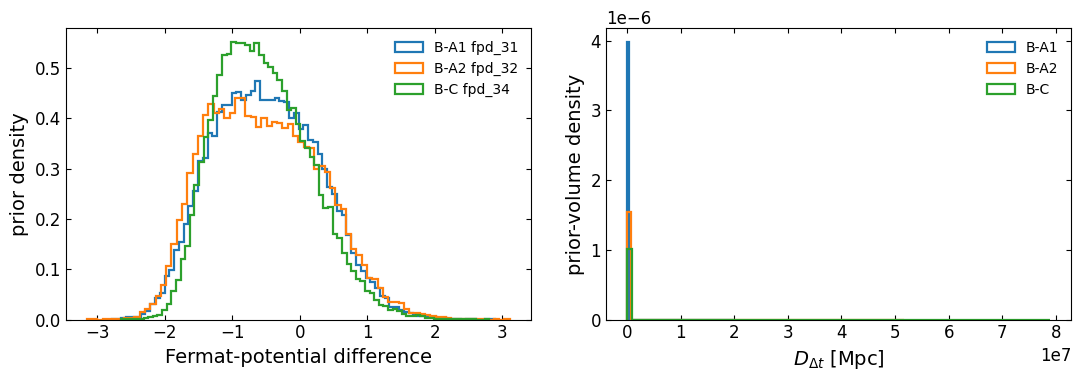

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for fpd_name, obs in TIME_DELAY_OBS.items():
    x = np.asarray(prior_np[fpd_name], dtype=float)
    ax[0].hist(x[np.isfinite(x)], bins=80, density=True, histtype='step', lw=1.6, label=f"{obs['pair']} {fpd_name}")
    ddt = ddt_samples[f'Ddt_{obs["pair"]}_Mpc']
    good = np.isfinite(ddt) & (ddt > 0.0)
    ax[1].hist(ddt[good], bins=80, density=True, histtype='step', lw=1.6, label=obs['pair'])

ax[0].set_xlabel('Fermat-potential difference')
ax[0].set_ylabel('prior density')
ax[0].legend(frameon=False, fontsize=10)

ax[1].set_xlabel(r'$D_{\Delta t}$ [Mpc]')
ax[1].set_ylabel('prior-volume density')
ax[1].legend(frameon=False, fontsize=10)

for axis in ax:
    axis.tick_params(axis='both', direction='in', top=True, right=True)

fig.tight_layout()
plt.show()

In [7]:
if HAVE_CORNER:
    corner_df = pd.DataFrame({
        'fpd_31': np.asarray(prior_np['fpd_31'], dtype=float),
        'fpd_32': np.asarray(prior_np['fpd_32'], dtype=float),
        'fpd_34': np.asarray(prior_np['fpd_34'], dtype=float),
        'Ddt_BA1': ddt_samples['Ddt_B-A1_Mpc'],
        'Ddt_BA2': ddt_samples['Ddt_B-A2_Mpc'],
        'Ddt_BC': ddt_samples['Ddt_B-C_Mpc'],
    })
    finite = np.isfinite(corner_df).all(axis=1) & (corner_df[['Ddt_BA1', 'Ddt_BA2', 'Ddt_BC']] > 0.0).all(axis=1)
    fig = corner.corner(
        corner_df.loc[finite],
        labels=[r'$\Delta\phi_{31}$', r'$\Delta\phi_{32}$', r'$\Delta\phi_{34}$', r'$D_{\Delta t}^{\rm BA1}$', r'$D_{\Delta t}^{\rm BA2}$', r'$D_{\Delta t}^{\rm BC}$'],
        color='#356ab7',
        levels=[0.68, 0.95],
        plot_datapoints=False,
        fill_contours=True,
        hist_kwargs={'density': True, 'histtype': 'step', 'linewidth': 1.5},
        max_n_ticks=4,
    )
    plt.show()
else:
    print('corner is not installed in this kernel; skipping corner plot.')

AttributeError: 'function' object has no attribute 'corner'